In [1]:
import os
import numpy as np
from tqdm import tqdm
from PIL import Image
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from sklearn.metrics import jaccard_score, f1_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, random_split

import torchvision
import torchvision.transforms.functional as F
import torchvision.transforms.v2 as transforms

import itertools
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
import json
from pathlib import Path
from datetime import datetime

In [2]:
@dataclass
class Config:
    image_size: tuple = (128, 128)
    batch_size: int = 32
    epochs: int = 15
    learning_rate: float = 0.0001
    device: str = field(default_factory=lambda: "cuda" if torch.cuda.is_available() else "cpu")
    train_split: int = 0.8

    def to_dict(self):
        """Для совместимости с visualizer.save_run()"""
        return {
            'image_size': self.image_size,
            'batch_size': self.batch_size,
            'epochs': self.epochs,
            'learning_rate': self.learning_rate,
            'device': self.device,
            'train_split': self.train_split,
        }

config = Config()

In [3]:
def Sequent(in_channels, out_channels, kernel, padding):
  return nn.Sequential(
    nn.Conv2d(in_channels, out_channels, kernel, padding=padding),
    nn.ReLU(inplace=True),
  )

In [4]:
class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.resnet = torchvision.models.resnet34(pretrained=True)
        self.layers = list(self.resnet.children())

        self.layer0 = nn.Sequential(*self.layers[:3]) # size=(N, 64, x.H/2, x.W/2)
        self.layer0_1x1 = Sequent(64, 64, 1, 0)
        self.layer1 = nn.Sequential(*self.layers[3:5]) # size=(N, 64, x.H/4, x.W/4)
        self.layer1_1x1 = Sequent(64, 64, 1, 0)
        self.layer2 = self.layers[5]  # size=(N, 128, x.H/8, x.W/8)
        self.layer2_1x1 = Sequent(128, 128, 1, 0)
        self.layer3 = self.layers[6]  # size=(N, 256, x.H/16, x.W/16)
        self.layer3_1x1 = Sequent(256, 256, 1, 0)
        self.layer4 = self.layers[7]  # size=(N, 512, x.H/32, x.W/32)
        self.layer4_1x1 = Sequent(512, 512, 1, 0)

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.conv_up3 = Sequent(256 + 512, 512, 3, 1)
        self.conv_up2 = Sequent(128 + 512, 256, 3, 1)
        self.conv_up1 = Sequent(64 + 256, 256, 3, 1)
        self.conv_up0 = Sequent(64 + 256, 128, 3, 1)

        self.conv_original_size0 = Sequent(3, 64, 3, 1)
        self.conv_original_size1 = Sequent(64, 64, 3, 1)
        self.conv_original_size2 = Sequent(64 + 128, 64, 3, 1)

        self.conv_last = nn.Conv2d(64, out_channels, 1)

        # тут слои обозначить для encoder, bottleneck и decoder

    def forward(self, x):
        # тут предсказать маску
                # Encoder
        x_original = self.conv_original_size0(x)
        x_original = self.conv_original_size1(x_original)

        layer0 = self.layer0(x)
        layer1 = self.layer1(layer0)
        layer2 = self.layer2(layer1)
        layer3 = self.layer3(layer2)
        layer4 = self.layer4(layer3)

        # Bottleneck
        layer4 = self.layer4_1x1(layer4)

        # Decoder with skip connections (конкатенация, а не сложение)
        x = self.upsample(layer4)
        layer3 = self.layer3_1x1(layer3)
        x = torch.cat([x, layer3], dim=1)
        x = self.conv_up3(x)

        x = self.upsample(x)
        layer2 = self.layer2_1x1(layer2)
        x = torch.cat([x, layer2], dim=1)
        x = self.conv_up2(x)

        x = self.upsample(x)
        layer1 = self.layer1_1x1(layer1)
        x = torch.cat([x, layer1], dim=1)
        x = self.conv_up1(x)

        x = self.upsample(x)
        layer0 = self.layer0_1x1(layer0)
        x = torch.cat([x, layer0], dim=1)
        x = self.conv_up0(x)

        x = self.upsample(x)
        x = torch.cat([x, x_original], dim=1)
        x = self.conv_original_size2(x)

        out = self.conv_last(x)
        return out

In [5]:
class PetDataset(Dataset):
    def __init__(self, root, split='trainval', transform=None):
        self.root = root
        self.transform = transform
        self.dataset = torchvision.datasets.OxfordIIITPet(root=root, split=split, target_types='segmentation', download=True)

    def __len__(self):
        return len(self.dataset)

    def __getitem__(self, idx):
        image, mask = self.dataset[idx]

        mask = np.array(mask)
        mask = (mask > 1).astype(np.uint8)
        mask = Image.fromarray(mask)

        if self.transform:
            image = self.transform(image)

        mask = mask.resize((128, 128))
        mask = F.pil_to_tensor(mask).float()

        return image, mask

In [6]:
class DiceLoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth

    def forward(self, preds, targets):
        preds = torch.sigmoid(preds)  # Применяем сигмоиду внутри лосса
        preds = preds.view(-1)
        targets = targets.view(-1)

        intersection = (preds * targets).sum()
        dice = (2. * intersection + self.smooth) / (preds.sum() + targets.sum() + self.smooth)
        return 1 - dice  # Возвращаем 1 - Dice, так как нам нужно минимизировать лосс

In [7]:
class HyperparamVisualizer:
    def __init__(self, results_dir='hyperparam_results'):
        self.results_dir = Path(results_dir)
        self.results_dir.mkdir(exist_ok=True)
        self.results = []

    def save_run(self, config, history, metrics, run_name=None):
        """Сохраняет результаты одного запуска"""
        if run_name is None:
            run_name = datetime.now().strftime("%Y%m%d_%H%M%S")

        data = {
            'run_name': run_name,
            'config': config.to_dict() if hasattr(config, 'to_dict') else config,
            'history': {k: [float(v) for v in vals] for k, vals in history.items()},
            'final_metrics': metrics,
            'timestamp': datetime.now().isoformat()
        }

        filepath = self.results_dir / f"{run_name}.json"
        with open(filepath, 'w') as f:
            json.dump(data, f, indent=2)

        self.results.append(data)
        print(f"Saved: {filepath}")
        return filepath

    def load_all_runs(self):
        """Загружает все сохранённые запуски"""
        self.results = []
        for filepath in self.results_dir.glob("*.json"):
            with open(filepath, 'r') as f:
                self.results.append(json.load(f))
        print(f"Loaded {len(self.results)} runs from {self.results_dir}")
        return self.results

    def plot_training_curves(self, run_names=None, metrics=['train_loss', 'val_loss', 'val_iou']):
        """Графики обучения для выбранных запусков"""
        if not self.results:
            self.load_all_runs()

        if run_names:
            results = [r for r in self.results if r['run_name'] in run_names]
        else:
            results = self.results[:5]  # По умолчанию первые 5

        fig, axes = plt.subplots(2, 2, figsize=(20, 15)) # Increased figsize
        fig.suptitle('Training Curves Comparison', fontsize=16, fontweight='bold')

        colors = plt.cm.tab10(np.linspace(0, 1, len(results)))

        for idx, result in enumerate(results):
            label = f"{result['run_name']}\nLR:{result['config'].get('learning_rate', 'N/A')}"
            color = colors[idx]
            history = result['history']
            epochs = range(1, len(history.get('train_loss', [])) + 1)

            # Train/Val Loss
            if 'train_loss' in history:
                axes[0, 0].plot(epochs, history['train_loss'], label=f"{label} (train)",
                               color=color, linestyle='-')
            if 'val_loss' in history:
                axes[0, 0].plot(epochs, history['val_loss'], label=f"{label} (val)",
                               color=color, linestyle='--')

            # IoU
            if 'val_iou' in history:
                axes[0, 1].plot(epochs, history['val_iou'], label=label, color=color)

            # F1-Score
            if 'val_f1' in history:
                axes[1, 0].plot(epochs, history['val_f1'], label=label, color=color)

        # Настройка графиков
        axes[0, 0].set_title('Loss')
        axes[0, 0].set_xlabel('Epoch')
        axes[0, 0].set_ylabel('Loss')
        axes[0, 0].legend(fontsize=8, loc='upper right')
        axes[0, 0].grid(True, alpha=0.3)

        axes[0, 1].set_title('Validation IoU')
        axes[0, 1].set_xlabel('Epoch')
        axes[0, 1].set_ylabel('IoU')
        axes[0, 1].legend(fontsize=8)
        axes[0, 1].grid(True, alpha=0.3)

        axes[1, 0].set_title('Validation F1-Score')
        axes[1, 0].set_xlabel('Epoch')
        axes[1, 0].set_ylabel('F1')
        axes[1, 0].legend(fontsize=8)
        axes[1, 0].grid(True, alpha=0.3)

        axes[1, 1].axis('off')  # Пустой подграфик
        axes[1, 1].text(0.5, 0.5, 'Metrics Summary',
                       ha='center', va='center', fontsize=12, fontweight='bold')

        # Таблица с финальными метриками
        if results:
            table_data = []
            for r in results:
                table_data.append([
                    r['run_name'][:15],
                    f"{r['final_metrics'].get('val_loss', 0):.4f}",
                    f"{r['final_metrics'].get('val_iou', 0):.4f}",
                    f"{r['final_metrics'].get('val_f1', 0):.4f}"
                ])

            axes[1, 1].axis('tight')
            axes[1, 1].axis('off')
            table = axes[1, 1].table(cellText=table_data,
                                    colLabels=['Run', 'Val Loss', 'IoU', 'F1'],
                                    loc='center', cellLoc='center')
            table.auto_set_font_size(False)
            table.set_fontsize(9)
            table.scale(1.2, 1.5)

        plt.tight_layout()
        plt.savefig(self.results_dir / 'training_curves.png', dpi=300, bbox_inches='tight')
        plt.show()

    def plot_hyperparam_comparison(self, param_name, metric='val_iou'):
        """Сравнение одного гиперпараметра по выбранной метрике"""
        if not self.results:
            self.load_all_runs()

        # Группировка по значению гиперпараметра
        data = []
        for r in self.results:
            param_val = r['config'].get(param_name)
            metric_val = r['final_metrics'].get(metric)
            if param_val is not None and metric_val is not None:
                data.append({param_name: param_val, metric: metric_val})

        if not data:
            print(f"No data for param='{param_name}' and metric='{metric}'")
            return

        df = pd.DataFrame(data)

        # Агрегация (среднее + стандартное отклонение если есть повторы)
        if len(df) > 1:
            summary = df.groupby(param_name)[metric].agg(['mean', 'std', 'count']).reset_index()
        else:
            summary = df

        # Визуализация
        plt.figure(figsize=(10, 6))

        if summary['std'].notna().any() and (summary['std'] > 0).any():
            # С ошибкой если есть вариация
            plt.errorbar(summary[param_name], summary['mean'],
                        yerr=summary['std'], capsize=5, marker='o', linestyle='-')
        else:
            plt.plot(summary[param_name], summary[metric], marker='o', linestyle='-')

        plt.xlabel(param_name.replace('_', ' ').title())
        plt.ylabel(metric.upper())
        plt.title(f'{metric.upper()} vs {param_name.replace("_", " ").title()}')
        plt.grid(True, alpha=0.3)

        # Логарифмическая шкала для learning_rate
        if param_name == 'learning_rate':
            plt.xscale('log')

        plt.tight_layout()
        plt.savefig(self.results_dir / f'{param_name}_vs_{metric}.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Вывод таблицы
        print(f"\n{metric.upper()} by {param_name}:")
        print(summary.to_string(index=False))

        # Лучшее значение
        best_idx = summary[metric].idxmax() if 'mean' not in summary.columns else summary['mean'].idxmax()
        best_val = summary.iloc[best_idx][param_name]
        best_score = summary.iloc[best_idx]['mean'] if 'mean' in summary.columns else summary.iloc[best_idx][metric]
        print(f"Best {param_name}: {best_val} \u2192 {metric}={best_score:.4f}")

    def plot_heatmap(self, param_x='learning_rate', param_y='batch_size', metric='val_iou'):
        """Тепловая карта для двух гиперпараметров"""
        if not self.results:
            self.load_all_runs()

        # Сбор данных
        data = []
        for r in self.results:
            x_val = r['config'].get(param_x)
            y_val = r['config'].get(param_y)
            m_val = r['final_metrics'].get(metric)
            if all(v is not None for v in [x_val, y_val, m_val]):
                data.append({param_x: x_val, param_y: y_val, metric: m_val})

        if len(data) < 4:
            print(f"Need at least 4 combinations for heatmap, got {len(data)}")
            return

        df = pd.DataFrame(data)

        # Pivot table для heatmap
        pivot = df.pivot_table(index=param_y, columns=param_x, values=metric, aggfunc='mean')

        plt.figure(figsize=(10, 8))
        sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', cbar_kws={'label': metric.upper()})
        plt.title(f'{metric.upper()} Heatmap: {param_y} vs {param_x}')
        plt.xlabel(param_x.replace('_', ' ').title())
        plt.ylabel(param_y.replace('_', ' ').title())

        # Логарифмическая подпись для LR
        if param_x == 'learning_rate':
            plt.xticks(rotation=45, ha='right')

        plt.tight_layout()
        plt.savefig(self.results_dir / f'heatmap_{param_x}_{param_y}.png', dpi=300, bbox_inches='tight')
        plt.show()

        # Лучшая комбинация
        best = df.loc[df[metric].idxmax()]
        print(f"\nBest combination:")
        print(f"  {param_x}: {best[param_x]}")
        print(f"  {param_y}: {best[param_y]}")
        print(f"  {metric}: {best[metric]:.4f}")

    def get_best_config(self, metric='val_iou'):
        """Возвращает конфигурацию с лучшей метрикой"""
        if not self.results:
            self.load_all_runs()

        if not self.results:
            return None

        best_run = max(self.results, key=lambda r: r['final_metrics'].get(metric, 0))
        return {
            'config': best_run['config'],
            'metrics': best_run['final_metrics'],
            'run_name': best_run['run_name']
        }

    def export_summary(self, filename='summary.csv'):
        """Экспорт сводной таблицы в CSV"""
        if not self.results:
            self.load_all_runs()

        rows = []
        for r in self.results:
            row = {}
            # Параметры
            for k, v in r['config'].items():
                row[f'param_{k}'] = v
            # Метрики
            for k, v in r['final_metrics'].items():
                row[f'metric_{k}'] = v
            row['run_name'] = r['run_name']
            row['timestamp'] = r['timestamp']
            rows.append(row)

        df = pd.DataFrame(rows)
        filepath = self.results_dir / filename
        df.to_csv(filepath, index=False)
        print(f"Exported summary: {filepath}")
        return df

In [8]:
class Trainer:
    def __init__(self, config, visualizer=None):
        self.config = config
        self.visualizer = visualizer

        self.transform = transforms.Compose([
            transforms.Resize(config.image_size),
            transforms.ToTensor(),
            transforms.Normalize(mean=[0.5], std=[0.5])
        ])

        self.model = UNet().to(config.device)
        self.criterion_bce = nn.BCEWithLogitsLoss()
        self.criterion_dice = DiceLoss()
        self.optimizer = optim.Adam(self.model.parameters(), lr=config.learning_rate)

        self.setup_dataloader()
        self.history = {
            'train_loss': [],
            'val_loss': [],
            'val_iou': [],
            'val_f1': []
        }

    def setup_dataloader(self):
        dataset = PetDataset(root="./data", split='trainval', transform=self.transform)
        train_size = int(self.config.train_split * len(dataset))
        val_size = len(dataset) - train_size

        train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
        self.test_dataset = PetDataset(root="./data", split='test', transform=self.transform)

        self.train_dataloader = DataLoader(train_dataset, batch_size=self.config.batch_size, shuffle=True)
        self.val_dataloader = DataLoader(val_dataset, batch_size=self.config.batch_size, shuffle=False)
        self.test_dataloader = DataLoader(self.test_dataset, batch_size=self.config.batch_size, shuffle=False)

    def run(self):
        self.history = {'train_loss': [], 'val_loss': [], 'val_iou': [], 'val_f1': []}
        for epoch in range(self.config.epochs):
            train_loss = self.train()
            val_loss, val_iou, val_f1 = self.validate()

            self.history['train_loss'].append(train_loss)
            self.history['val_loss'].append(val_loss)
            self.history['val_iou'].append(val_iou)
            self.history['val_f1'].append(val_f1)

            print(f"Epoch {epoch+1} / {self.config.epochs}, "
                  f"Train Loss: {train_loss:.4f}, "
                  f"Val Loss: {val_loss:.4f}, "
                  f"Val IoU: {val_iou:.4f}, "
                  f"Val F1-score: {val_f1:.4f}")


        print('Testing...')
        test_loss, test_iou, test_f1 = self.test()

        print(f"Test Loss: {test_loss:.4f}, "
              f"Test IoU: {test_iou:.4f}, "
              f"Test F1-score: {test_f1:.4f}")

        final_metrics = {
            'val_loss': float(min(self.history['val_loss'])),
            'val_iou': float(max(self.history['val_iou'])),
            'val_f1': float(max(self.history['val_f1'])),
            'test_loss': float(test_loss),
            'test_iou': float(test_iou),
            'test_f1': float(test_f1),
        }

        if self.visualizer:
            run_name = f"lr{self.config.learning_rate}_bs{self.config.batch_size}"
            self.visualizer.save_run(
                config=self.config,
                history=self.history,
                metrics=final_metrics,
                run_name=run_name
            )
        return self.history, final_metrics

    def train(self):
        self.model.train()
        epoch_loss = 0

        for images, masks in tqdm(self.train_dataloader):
            images = images.to(self.config.device)
            masks = masks.to(self.config.device)

            self.optimizer.zero_grad()
            outputs = self.model(images)

            loss_bce = self.criterion_bce(outputs, masks)
            loss_dice = self.criterion_dice(outputs, masks)
            loss = loss_bce + loss_dice
            loss.backward()
            self.optimizer.step()

            epoch_loss += loss.item()

        return epoch_loss / len(self.train_dataloader)

    def validate(self):
        self.model.eval()
        val_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.val_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss_bce = self.criterion_bce(outputs, masks)
                loss_dice = self.criterion_dice(outputs, masks)
                loss = loss_bce + loss_dice
                # loss = self.criterion(outputs, masks)
                val_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return val_loss / len(self.val_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def test(self):
        self.model.eval()
        test_loss = 0
        iou_scores, f1_scores = [], []

        with torch.no_grad():
            for images, masks in tqdm(self.test_dataloader):
                images = images.to(self.config.device)
                masks = masks.to(self.config.device)

                outputs = self.model(images)
                loss_bce = self.criterion_bce(outputs, masks)
                loss_dice = self.criterion_dice(outputs, masks)
                loss = loss_bce + loss_dice
                test_loss += loss.item()

                pred_masks = (torch.sigmoid(outputs).cpu().numpy() > 0.5).astype(np.uint8)
                masks = masks.squeeze(1).cpu().numpy().astype(np.uint8)

                for i in range(len(pred_masks)):
                    iou_scores.append(jaccard_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))
                    f1_scores.append(f1_score(masks[i].flatten(), pred_masks[i].flatten(), average='binary'))

        return test_loss / len(self.test_dataloader), np.mean(iou_scores), np.mean(f1_scores)

    def inference_and_plot_samples(self, n_samples=3):
        self.model.eval()

        with torch.no_grad():
            fig, axes = plt.subplots(n_samples, 3, figsize=(10, 3 * n_samples))

            for i in range(n_samples):
                img, mask = self.test_dataset[i]
                img_tensor = img.unsqueeze(0).to(self.config.device)

                output = self.model(img_tensor)
                output = torch.sigmoid(output).squeeze().cpu().numpy()
                output = (output >= 0.5).astype('float')

                axes[i, 0].imshow(img.permute(1, 2, 0).cpu())
                axes[i, 0].set_title("Image")
                axes[i, 1].imshow(mask.squeeze().cpu(), cmap="gray")
                axes[i, 1].set_title("Ground Truth")
                axes[i, 2].imshow(output, cmap="gray")
                axes[i, 2].set_title("Predicted Mask")

            plt.show()

In [9]:

def plot_results(results, lrs, bss):
    import matplotlib.pyplot as plt
    import numpy as np

    metrics = ['val_loss', 'val_iou', 'val_f1']
    fig, axes = plt.subplots(1, len(metrics), figsize=(15, 5))

    for idx, metric in enumerate(metrics):
        ax = axes[idx]
        for bs in bss:
            values = []
            corresponding_lrs = []

            for lr in lrs:
                key = (lr, bs)
                if key in results:
                    value = results[key].get(metric)
                    if value is not None:
                        values.append(value)
                        corresponding_lrs.append(lr)

            if values:
                ax.plot(corresponding_lrs, values, label=f'Batch Size {bs}', marker='o')

        ax.set_xlabel('Learning Rate')
        ax.set_ylabel(metric.replace('_', ' ').title())
        ax.set_title(f'{metric.replace("_", " ").title()} vs Learning Rate')
        ax.legend()
        ax.grid(True)

    plt.tight_layout()
    plt.show()


def hyperparameter_search():
    visualizer = HyperparamVisualizer(results_dir='hyperparam_results')

    learning_rates = [0.0001, 0.01, 0.05]
    batch_sizes = [16, 32, 64]
    default_config_instance = Config()
    fixed_epochs = default_config_instance.epochs

    results_for_plot = {}

    total_combinations = len(learning_rates) * len(batch_sizes)
    print(f"Total combinations: {total_combinations}")
    print("=" * 60)

    combo_num_counter = 0
    for lr in learning_rates:
        for bs in batch_sizes:
            combo_num_counter += 1
            print(f"\n[{combo_num_counter}/{total_combinations}] Testing: LR={lr}, BS={bs}")
            print("-" * 60)

            config = Config(
                learning_rate=lr,
                batch_size=bs,
                epochs=fixed_epochs,
                device="cuda" if torch.cuda.is_available() else "cpu",
                train_split=0.8
            )

            trainer = Trainer(config, visualizer=visualizer)

            try:
                history, metrics = trainer.run()
                key = (lr, bs)

                val_loss = history.get('val_loss', [float('inf')])[-1] if history.get('val_loss') else float('inf')
                val_iou = metrics.get('val_iou', 0)
                val_f1 = metrics.get('val_f1', 0)

                if (key not in results_for_plot or
                    val_iou > results_for_plot[key].get('val_iou', 0)):

                    results_for_plot[key] = {
                        'val_loss': val_loss,
                        'val_iou': val_iou,
                        'val_f1': val_f1,
                        'config': config.to_dict(),
                        'full_metrics': metrics,
                        'epoch': fixed_epochs
                    }

                print(f"Completed. Val IoU: {val_iou:.4f}, Val Loss: {val_loss:.4f}")

            except Exception as e:
                print(f"Error: {e}")
                import traceback
                traceback.print_exc()
                key = (lr, bs)
                if key not in results_for_plot:
                    results_for_plot[key] = {
                        'val_loss': float('inf'),
                        'val_iou': 0,
                        'val_f1': 0,
                        'error': str(e)
                    }
                continue

    print(f"\nResults summary:")
    print(f"   Successfully tested combinations: {len(results_for_plot)}")
    print(f"   Expected combinations: {len(learning_rates) * len(batch_sizes)}")

    for (lr, bs), result in results_for_plot.items():
        if 'error' in result:
            print(f"   ({lr}, {bs}): ERROR - {result['error'][:50]}...")
        else:
            print(f"   ({lr}, {bs}): IoU={result['val_iou']:.4f}, F1={result['val_f1']:.4f}")
    print("\n" + "=" * 60)
    print("Search completed! Generating visualizations...")
    print("=" * 60)

    visualizer.plot_training_curves()
    visualizer.plot_hyperparam_comparison('learning_rate', metric='val_iou')
    visualizer.plot_hyperparam_comparison('batch_size', metric='val_iou')

    best = visualizer.get_best_config(metric='val_iou')
    print(f"\nBEST CONFIGURATION:")
    print(f"   Learning Rate: {best['config']['learning_rate']}")
    print(f"   Batch Size: {best['config']['batch_size']}")
    print(f"   Epochs: {best['config']['epochs']}")
    print(f"   Val IoU: {best['metrics']['val_iou']:.4f}")
    print(f"   Test IoU: {best['metrics']['test_iou']:.4f}")

    visualizer.export_summary()

    print("\nPlotting results for learning rate and batch size comparison...")
    plot_results(results_for_plot, learning_rates, batch_sizes)
    return best


In [10]:
trainer = Trainer(config)

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet34-b627a593.pth" to /root/.cache/torch/hub/checkpoints/resnet34-b627a593.pth


100%|██████████| 83.3M/83.3M [00:00<00:00, 136MB/s]
100%|██████████| 792M/792M [00:35<00:00, 22.6MB/s]
100%|██████████| 19.2M/19.2M [00:01<00:00, 11.4MB/s]


In [11]:
trainer.run()

100%|██████████| 23/23 [00:11<00:00,  1.92it/s]


Epoch 1 / 15, Train Loss: 0.5810, Val Loss: 0.3337, Val IoU: 0.8652, Val F1-score: 0.9245


100%|██████████| 23/23 [00:10<00:00,  2.12it/s]


Epoch 2 / 15, Train Loss: 0.2310, Val Loss: 0.2080, Val IoU: 0.9106, Val F1-score: 0.9518


100%|██████████| 23/23 [00:10<00:00,  2.13it/s]


...

100%|██████████| 23/23 [00:10<00:00,  2.17it/s]


Epoch 15 / 15, Train Loss: 0.0781, Val Loss: 0.1894, Val IoU: 0.9288, Val F1-score: 0.9619
Testing...


100%|██████████| 115/115 [00:55<00:00,  2.07it/s]

Test Loss: 0.2192, Test IoU: 0.9244, Test F1-score: 0.9587


({'train_loss': [0.5809678030402764,
   0.2309528326858645,
   0.17366697655423827,
   0.1501447561642398,
   0.12990809912266937,
   0.11970310301884361,
   0.11091390365491742,
   0.10301136630384819,
   0.0998518999018099,
   0.09515588050303252,
   0.08860081863468108,
   0.08402372872375924,
   0.08141956300191257,
   0.0773264728486538,
   0.0780660986252453],
  'val_loss': [0.3337073986944945,
   0.20798829197883606,
   0.202766429470933,
   0.18856485252795013,
   0.18365263550177865,
   0.1843373594076737,
   0.17977816903072855,
   0.18592434214509052,
   0.18184854284576749,
   0.18377138998197473,
   0.18824958023817642,
   0.18656227770059006,
   0.1804638569769652,
   0.1919959738202717,
   0.1893932774015095],
  'val_iou': [np.float64(0.865180077940641),
   np.float64(0.9106388846757597),
   np.float64(0.9143716406539343),
   np.float64(0.9184425003511466),
   np.float64(0.9212545170431704),
   np.float64(0.9228438063683518),
   np.float64(0.9237066947843845),
   np.floa

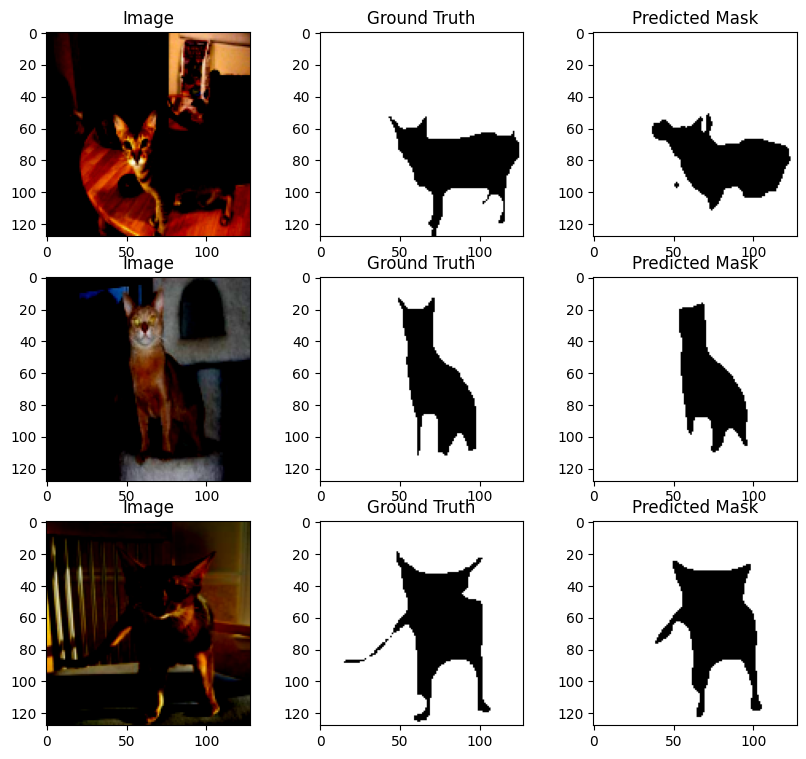

In [12]:
trainer.inference_and_plot_samples(n_samples=3)

Перебор гипперпараметров

Total combinations: 9

[1/9] Testing: LR=0.0001, BS=16
------------------------------------------------------------


/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 46/46 [00:11<00:00,  4.11it/s]


Epoch 1 / 15, Train Loss: 0.4638, Val Loss: 0.2343, Val IoU: 0.9024, Val F1-score: 0.9472


100%|██████████| 46/46 [00:11<00:00,  3.98it/s]


Epoch 2 / 15, Train Loss: 0.2054, Val Loss: 0.1991, Val IoU: 0.9135, Val F1-score: 0.9535


...

Epoch 14 / 15, Train Loss: 0.8874, Val Loss: 0.9038, Val IoU: 0.6951, Val F1-score: 0.8075


100%|██████████| 12/12 [00:10<00:00,  1.12it/s]


Epoch 15 / 15, Train Loss: 0.8873, Val Loss: 0.9041, Val IoU: 0.6951, Val F1-score: 0.8075
Testing...


100%|██████████| 58/58 [00:55<00:00,  1.05it/s]
/tmp/ipykernel_4736/1531726446.py:117: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


Test Loss: 0.8908, Test IoU: 0.7001, Test F1-score: 0.8107
Saved: hyperparam_results/lr0.05_bs64.json
Completed. Val IoU: 0.6951, Val Loss: 0.9041

Results summary:
   Successfully tested combinations: 9
   Expected combinations: 9
   (0.0001, 16): IoU=0.9323, F1=0.9641
   (0.0001, 32): IoU=0.9311, F1=0.9634
   (0.0001, 64): IoU=0.9242, F1=0.9591
   (0.01, 16): IoU=0.6987, F1=0.8115
   (0.01, 32): IoU=0.7103, F1=0.8198
   (0.01, 64): IoU=0.6999, F1=0.8125
   (0.05, 16): IoU=0.6965, F1=0.8093
   (0.05, 32): IoU=0.6966, F1=0.8101
   (0.05, 64): IoU=0.6951, F1=0.8075

Search completed! Generating visualizations...


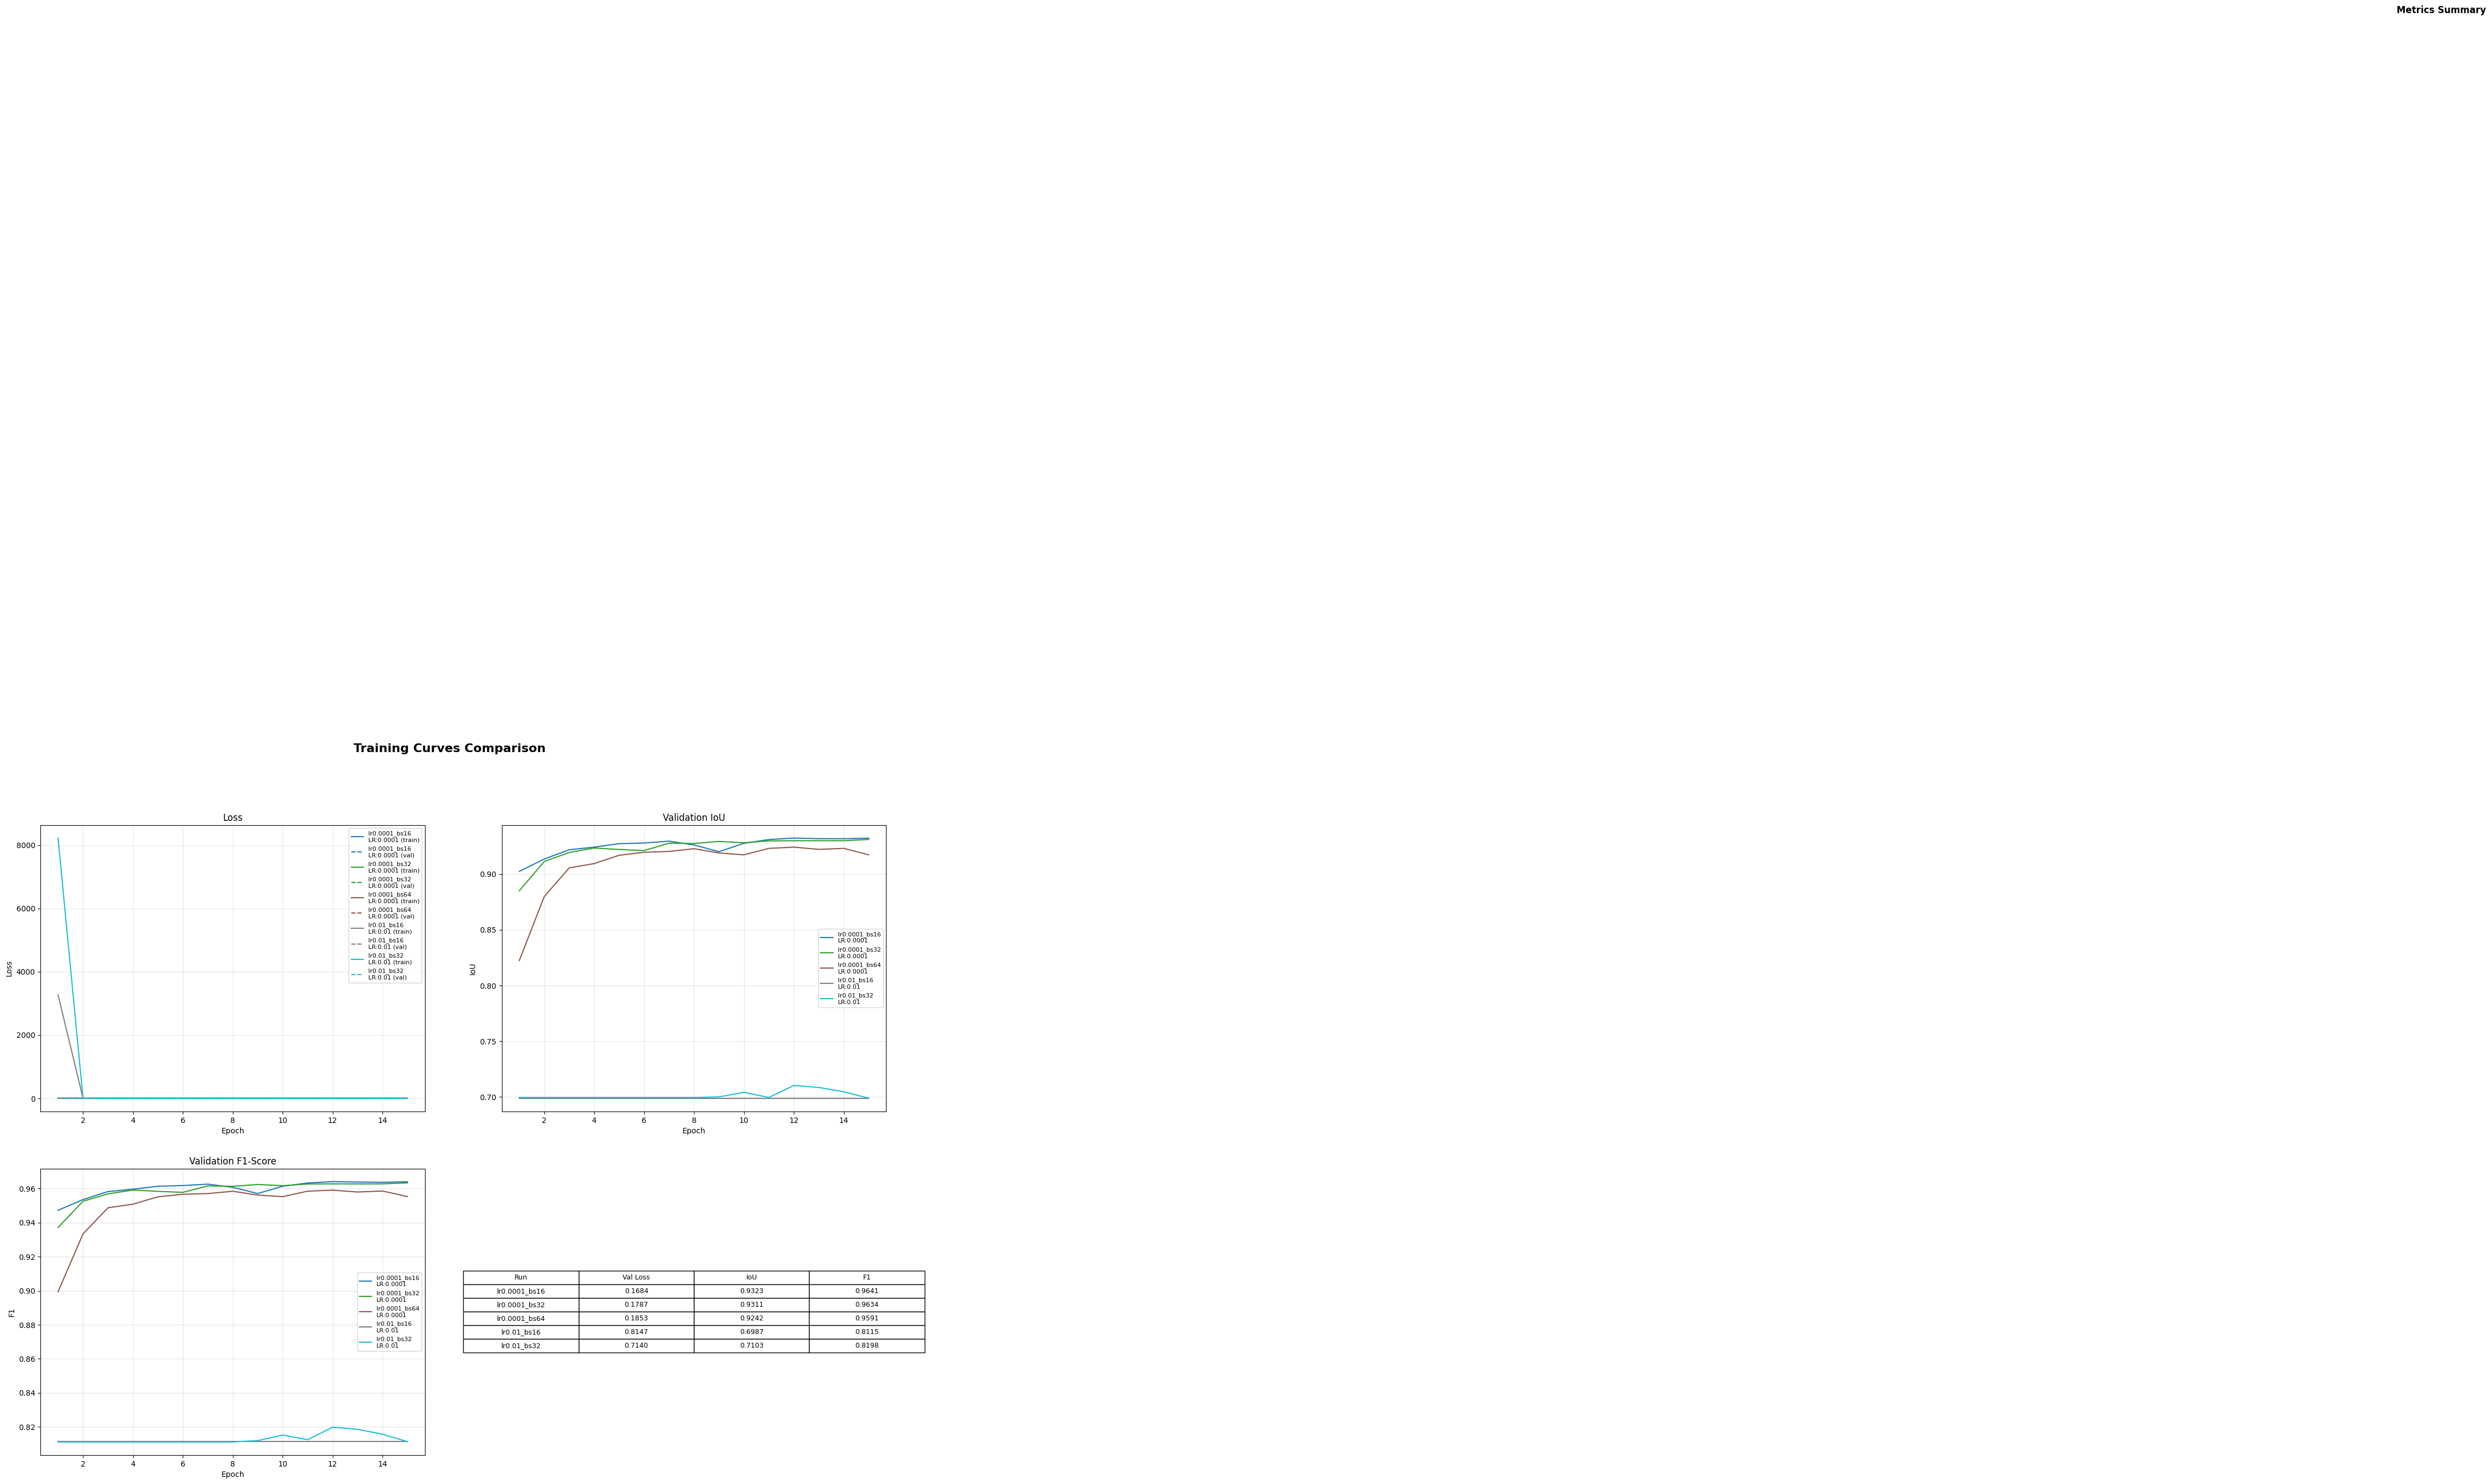

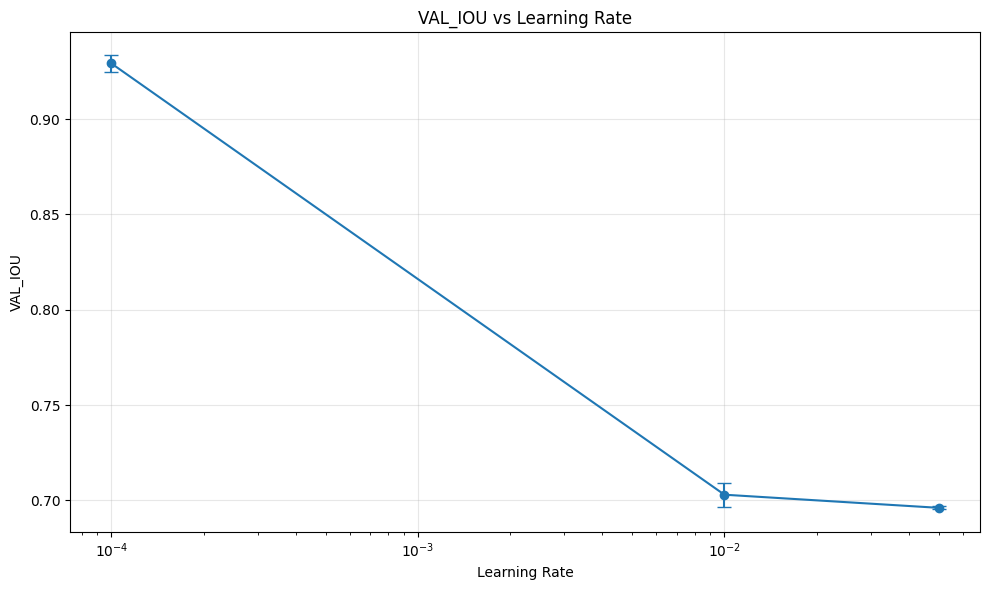


VAL_IOU by learning_rate:
 learning_rate     mean      std  count
        0.0001 0.929194 0.004405      3
        0.0100 0.702969 0.006366      3
        0.0500 0.696087 0.000829      3
Best learning_rate: 0.0001 → val_iou=0.9292


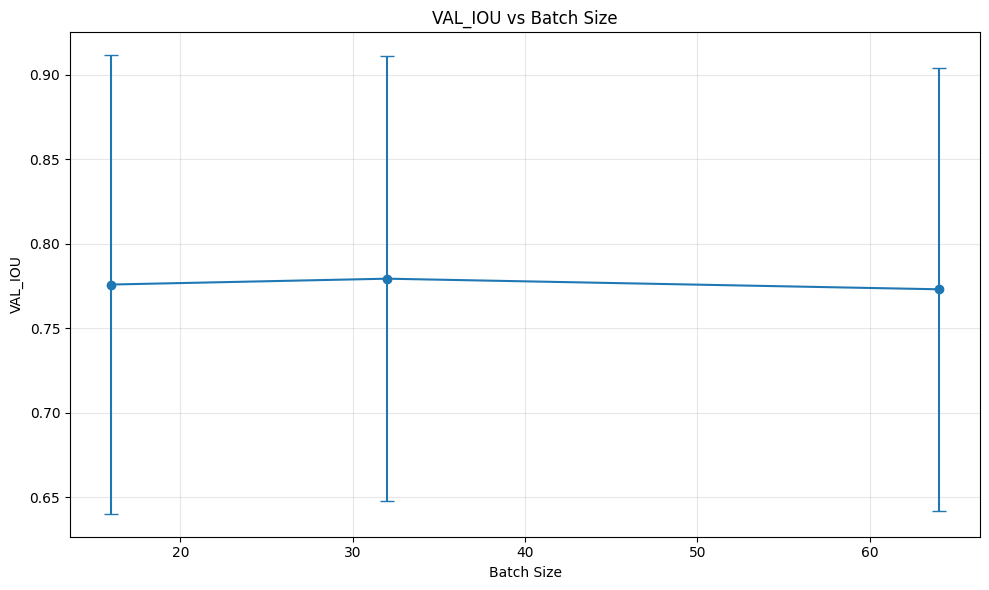


VAL_IOU by batch_size:
 batch_size     mean      std  count
         16 0.775870 0.135519      3
         32 0.779324 0.131595      3
         64 0.773056 0.130883      3
Best batch_size: 32.0 → val_iou=0.7793

BEST CONFIGURATION:
   Learning Rate: 0.0001
   Batch Size: 16
   Epochs: 15
   Val IoU: 0.9323
   Test IoU: 0.9259
Exported summary: hyperparam_results/summary.csv

Plotting results for learning rate and batch size comparison...


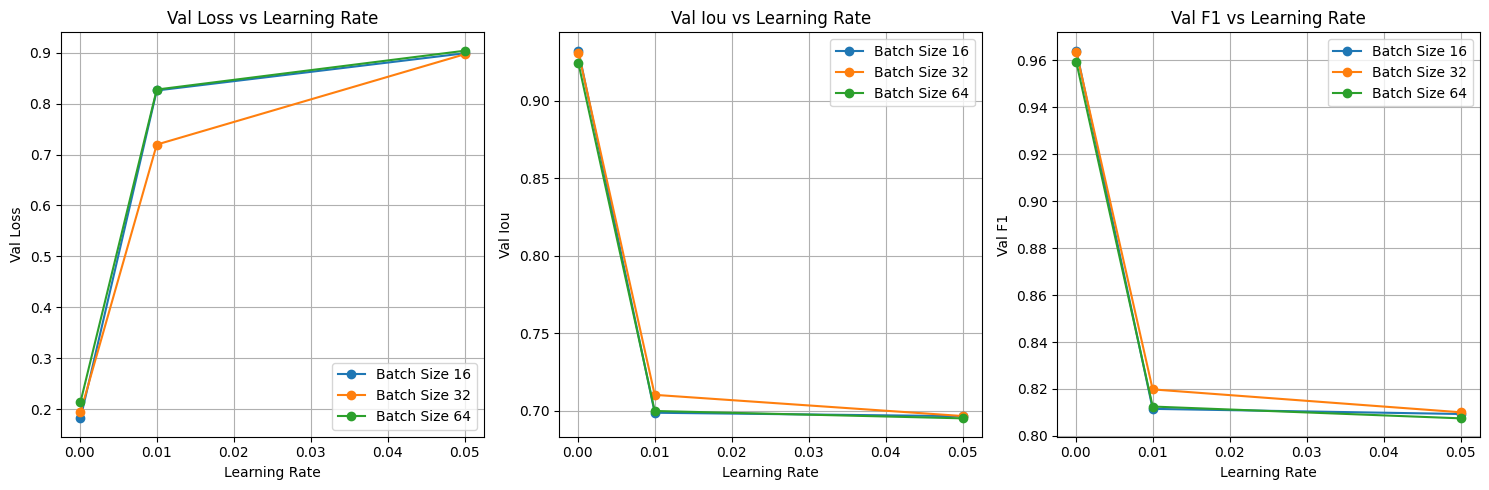

{'config': {'image_size': (128, 128),
  'batch_size': 16,
  'epochs': 15,
  'learning_rate': 0.0001,
  'device': 'cuda',
  'train_split': 0.8},
 'metrics': {'val_loss': 0.16835142202351405,
  'val_iou': 0.9323490880847057,
  'val_f1': 0.9640786259044276,
  'test_loss': 0.20932484638431798,
  'test_iou': 0.9258668471067939,
  'test_f1': 0.9595532361145882},
 'run_name': 'lr0.0001_bs16'}

In [13]:
hyperparameter_search()

**Выводы:**

Гиперпараметрический поиск выявил, что для оригинальной архитектуры U-Net оптимальными оказались следующие параметры: Learning Rate = 0.0001; Batch Size = 16. При этой конфигурации модель достигла Val IoU: 0.9323 и Test IoU: 0.9259. Среди протестированных комбинаций относительно низкая скорость обучения и меньший размер батча показали наилучшие результаты для исходной модели. 

Мысли про Learning Rate: сегментация требует высокой точности на границах объектов => низкий lr оказался плюсом.

Мысли про Batch Size: при большом батче усреднение градиентов не дало бы модели учиться на сложных объектах (с изменением освещения и т.д.) => маленький bs оказался плюсом.

**Модификация U-net**

Была добавлена нормализация для увеличения метрик сегментации

In [ ]:
class Sequent(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size, padding, activation=True):
        super(Sequent, self).__init__()
        layers = [
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels)  # Добавляем нормализацию
        ]
        if activation:
            layers.append(nn.ReLU(inplace=True))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1):
        super(UNet, self).__init__()

        self.resnet = torchvision.models.resnet34(pretrained=True)
        self.layers = list(self.resnet.children())

        self.layer0 = nn.Sequential(*self.layers[:3]) # size=(N, 64, x.H/2, x.W/2)
        self.layer0_1x1 = Sequent(64, 64, 1, 0)
        self.layer1 = nn.Sequential(*self.layers[3:5]) # size=(N, 64, x.H/4, x.W/4)
        self.layer1_1x1 = Sequent(64, 64, 1, 0)
        self.layer2 = self.layers[5]  # size=(N, 128, x.H/8, x.W/8)
        self.layer2_1x1 = Sequent(128, 128, 1, 0)
        self.layer3 = self.layers[6]  # size=(N, 256, x.H/16, x.W/16)
        self.layer3_1x1 = Sequent(256, 256, 1, 0)
        self.layer4 = self.layers[7]  # size=(N, 512, x.H/32, x.W/32)
        self.layer4_1x1 = Sequent(512, 512, 1, 0)

        self.upsample = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)

        self.conv_up3 = Sequent(256 + 512, 512, 3, 1)
        self.conv_up2 = Sequent(128 + 512, 256, 3, 1)
        self.conv_up1 = Sequent(64 + 256, 256, 3, 1)
        self.conv_up0 = Sequent(64 + 256, 128, 3, 1)

        self.conv_original_size0 = Sequent(3, 64, 3, 1)
        self.conv_original_size1 = Sequent(64, 64, 3, 1)
        self.conv_original_size2 = Sequent(64 + 128, 64, 3, 1)

        self.conv_last = nn.Conv2d(64, out_channels, 1)

    def forward(self, x):
        # Encoder
        x_original = self.conv_original_size0(x)
        x_original = self.conv_original_size1(x_original)

        layer0 = self.layer0(x)
        layer1 = self.layer1(layer0)
        layer2 = self.layer2(layer1)
        layer3 = self.layer3(layer2)
        layer4 = self.layer4(layer3)

        # Bottleneck
        layer4 = self.layer4_1x1(layer4)

        # Decoder with skip connections
        x = self.upsample(layer4)
        layer3 = self.layer3_1x1(layer3)
        x = torch.cat([x, layer3], dim=1)
        x = self.conv_up3(x)

        x = self.upsample(x)
        layer2 = self.layer2_1x1(layer2)
        x = torch.cat([x, layer2], dim=1)
        x = self.conv_up2(x)

        x = self.upsample(x)
        layer1 = self.layer1_1x1(layer1)
        x = torch.cat([x, layer1], dim=1)
        x = self.conv_up1(x)

        x = self.upsample(x)
        layer0 = self.layer0_1x1(layer0)
        x = torch.cat([x, layer0], dim=1)
        x = self.conv_up0(x)

        x = self.upsample(x)
        x = torch.cat([x, x_original], dim=1)
        x = self.conv_original_size2(x)

        out = self.conv_last(x)
        return out

/usr/local/lib/python3.12/dist-packages/torchvision/transforms/v2/_deprecated.py:42: UserWarning: The transform `ToTensor()` is deprecated and will be removed in a future release. Instead, please use `v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])`.Output is equivalent up to float precision.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████| 23/23 [00:10<00:00,  2.11it/s]


Epoch 1 / 15, Train Loss: 0.4978, Val Loss: 0.4096, Val IoU: 0.8987, Val F1-score: 0.9445


100%|██████████| 23/23 [00:10<00:00,  2.10it/s]


Epoch 2 / 15, Train Loss: 0.3623, Val Loss: 0.3468, Val IoU: 0.9132, Val F1-score: 0.9531


100%|██████████| 23/23 [00:10<00:00,  2.16it/s]


...

Epoch 14 / 15, Train Loss: 0.1108, Val Loss: 0.1955, Val IoU: 0.9262, Val F1-score: 0.9602


100%|██████████| 23/23 [00:11<00:00,  2.07it/s]


Epoch 15 / 15, Train Loss: 0.0982, Val Loss: 0.1917, Val IoU: 0.9300, Val F1-score: 0.9624
Testing...


100%|██████████| 115/115 [00:55<00:00,  2.08it/s]


Test Loss: 0.2068, Test IoU: 0.9252, Test F1-score: 0.9590


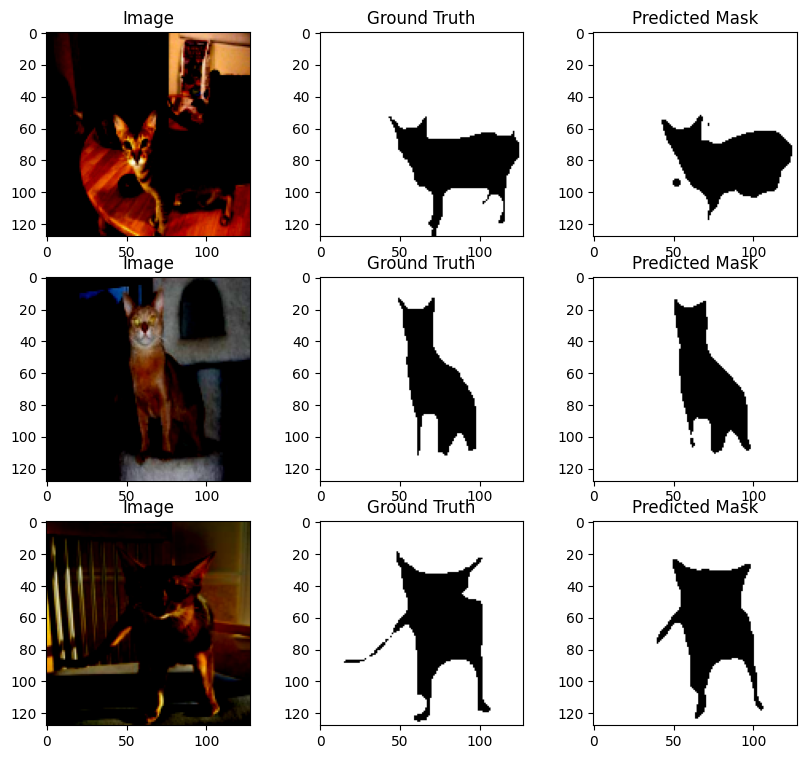

In [15]:
trainer = Trainer(config)
trainer.run()
trainer.inference_and_plot_samples(n_samples=3)

**Выводы:**
После модификации U-Net с добавлением слоёв пакетной нормализации, при запуске с конфигурацией Learning Rate = 0.0001 и Batch Size = 32 модель показала Test IoU: 0.9252. Это значение чуть-чуть (в пределах погрешности!) ниже, чем Test IoU, достигнутое лучшей конфигурацией оригинальной U-Net (0.9259), которая использовала Batch Size = 16. Это может указывать на то, что добавление BatchNorm помогло как минимум поддержать производительность даже с использованием большего размера батча, что потенциально ускоряет обучение без потери качества.

Мысли: BatchNorm выполняет функцию регуляризации, т.е. снижает чувствительность модели к выбору гиперпараметров.